# Biogas NPV simulation

Run the biogas electricity Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'biogas'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,lifetime_years,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,...,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_mwh,levelized_net_margin_eur_per_mwh
0,0,biogas,1000000.0,5300.0,25.0,188.679245,188679.245283,5708.295622,199.370242,3.992969,...,1.077037e+09,94070000.0,3.761703e+07,3.992969e+06,2.175877e+08,0.0,-1.651277e+08,-2.839738e+09,1.067478e+07,-266.023214
1,1,biogas,1000000.0,5300.0,25.0,188.679245,188679.245283,5777.735301,155.549537,3.641598,...,1.090139e+09,94070000.0,2.934897e+07,3.641598e+06,2.324231e+08,0.0,-1.713437e+08,-2.919194e+09,1.067478e+07,-273.466576
2,2,biogas,1000000.0,5300.0,25.0,188.679245,188679.245283,3306.980022,188.635767,3.940034,...,6.239585e+08,94070000.0,3.559165e+07,3.940034e+06,2.160749e+08,0.0,-1.615366e+08,-2.348325e+09,1.067478e+07,-219.988240
3,3,biogas,1000000.0,5300.0,25.0,188.679245,188679.245283,2913.020051,153.011276,4.669362,...,5.496264e+08,94070000.0,2.887005e+07,4.669362e+06,2.133051e+08,0.0,-1.527745e+08,-2.180460e+09,1.067478e+07,-204.262811
4,4,biogas,1000000.0,5300.0,25.0,188.679245,188679.245283,3795.199014,274.566202,4.426561,...,7.160753e+08,94070000.0,5.180494e+07,4.426561e+06,2.237777e+08,0.0,-1.859393e+08,-2.700935e+09,1.067478e+07,-253.020311


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_mwh = results["levelized_net_margin_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/MWh"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/MWh
count,100000.000000,100000.000000
mean,-2615.750090,-245.040275
std,208.377584,19.520558
min,-3229.591200,-302.544160
5%,-2961.651672,-277.443913
50%,-2615.747420,-245.040025
95%,-2273.757519,-213.002828
max,-2011.582484,-188.442591


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


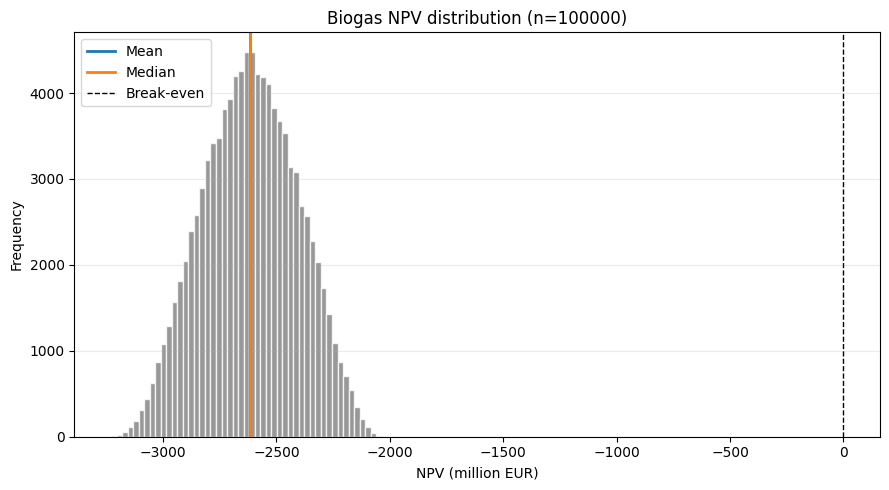

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## levelized net margin histogram


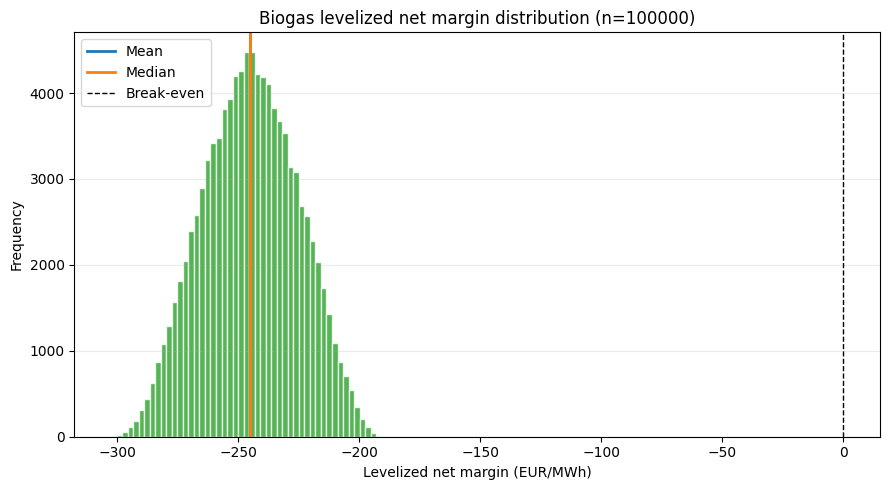

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur            94.070000
annual_fixed_opex_eur         37.126694
annual_variable_opex_eur       4.131659
annual_fuel_cost_eur         221.092188
annual_emissions_cost_eur      0.000000
annual_net_cash_flow_eur    -168.280542
Name: Mean annual value, million EUR, dtype: float64